# TP 1 — CNN sur MNIST : solution commentée

Solution complète du [TP 1](./enonce.ipynb).

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

torch.manual_seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_ROOT = "./data"

In [66]:
torch.cuda.is_available()

False

In [60]:
T = torch.Tensor([1, 2, 3])

In [61]:
T.device

device(type='cpu')

In [62]:
T.to('cuda')

AssertionError: Torch not compiled with CUDA enabled

In [65]:
model.to('cpu')

SmallCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)

## Exercice 1 — Données

In [20]:
from torch.utils.data import Dataset

In [42]:
class LDataset(Dataset):
    def __init__(self, L, y):
        self.L = L
        self.y = y

    def __len__(self):
        return len(self.L)

    def __getitem__(self, idx):
        return self.L[idx], self.y[idx]

In [43]:
P = torch.arange(1,10000)
y = torch.arange(2,10001)
d = LDataset(P, y)

In [44]:
dataloader = DataLoader(d, batch_size=10, shuffle=True)

In [45]:
for batch in dataloader:
    break

In [46]:
batch

[tensor([3833, 2084, 8311, 9556, 6854, 3954,  747, 8996, 6856, 5711]),
 tensor([3834, 2085, 8312, 9557, 6855, 3955,  748, 8997, 6857, 5712])]

In [28]:
len(d)

9999

In [29]:
d[67]

tensor(68)

In [79]:
tf = transforms.ToTensor()
train_full = datasets.MNIST(DATA_ROOT, train=True, download=True, transform=tf)
test_full = datasets.MNIST(DATA_ROOT, train=False, download=True, transform=tf)

In [49]:
x, y = train_ds[0]

In [52]:
for batch in train_loader:
    break

In [55]:
batch[0].shape

torch.Size([64, 1, 28, 28])

In [56]:
batch[1].shape

torch.Size([64])

In [67]:
import numpy as np

In [68]:
N = np.array([1, 2, 3])

In [69]:
T = torch.from_numpy(N)

In [71]:
N

array([1, 2, 3])

In [70]:
T

tensor([1, 2, 3])

In [72]:
T.numpy()

array([1, 2, 3])

In [75]:
x.shape

torch.Size([1, 28, 28])

In [77]:
x.squeeze().shape

torch.Size([28, 28])

In [78]:
x.resize(28, 28).shape

/Users/hamza.tajmouati/miniconda3/lib/python3.11/site-packages/torch/_tensor.py:1002: UserWarning: non-inplace resize is deprecated
  warnings.warn("non-inplace resize is deprecated")


torch.Size([28, 28])

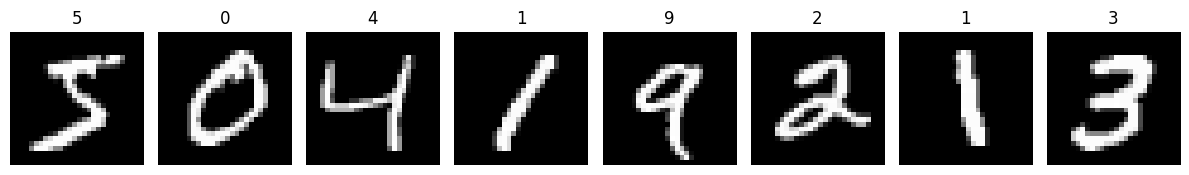

In [73]:
train_ds = Subset(train_full, range(3000))
test_ds = Subset(test_full, range(1000))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

# Aperçu
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i, (x, y) in enumerate(train_ds):
    if i >= 8:
        break
    axes[i].imshow(x.squeeze().numpy(), cmap="gray")
    axes[i].set_title(int(y))
    axes[i].axis("off")
plt.tight_layout()

## Exercice 2 — CNN

In [57]:
class SmallCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


model = SmallCNN().to(DEVICE)
print(model)
print("sortie test :", model(torch.zeros(1, 1, 28, 28).to(DEVICE)).shape)
n_params = sum(p.numel() for p in model.parameters())
print(f"paramètres : {n_params:,}")

SmallCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)
sortie test : torch.Size([1, 10])
paramètres : 105,866


## Exercice 3 — Boucle d'entraînement

In [9]:
def train_one_epoch(model, loader, opt, loss_fn):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        opt.step()
        total_loss += loss.item() * x.size(0)
        correct += (pred.argmax(1) == y).sum().item()
        n += x.size(0)
    return total_loss / n, correct / n


def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x)
            total_loss += loss_fn(pred, y).item() * x.size(0)
            correct += (pred.argmax(1) == y).sum().item()
            n += x.size(0)
    return total_loss / n, correct / n


opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
for epoch in range(50):
    tl, ta = train_one_epoch(model, train_loader, opt, loss_fn)
    vl, va = evaluate(model, test_loader, loss_fn)
    history["train_loss"].append(tl)
    history["train_acc"].append(ta)
    history["test_loss"].append(vl)
    history["test_acc"].append(va)
    print(f"epoch {epoch + 1}  train loss={tl:.3f} acc={ta:.3f}  test loss={vl:.3f} acc={va:.3f}")

epoch 1  train loss=0.245 acc=0.933  test loss=0.227 acc=0.923
epoch 2  train loss=0.184 acc=0.947  test loss=0.205 acc=0.928
epoch 3  train loss=0.150 acc=0.957  test loss=0.155 acc=0.949
epoch 4  train loss=0.117 acc=0.969  test loss=0.143 acc=0.952
epoch 5  train loss=0.095 acc=0.975  test loss=0.138 acc=0.955
epoch 6  train loss=0.079 acc=0.979  test loss=0.118 acc=0.963
epoch 7  train loss=0.065 acc=0.981  test loss=0.134 acc=0.953
epoch 8  train loss=0.054 acc=0.984  test loss=0.101 acc=0.971
epoch 9  train loss=0.042 acc=0.989  test loss=0.107 acc=0.965
epoch 10  train loss=0.044 acc=0.987  test loss=0.114 acc=0.964
epoch 11  train loss=0.032 acc=0.990  test loss=0.102 acc=0.963
epoch 12  train loss=0.021 acc=0.995  test loss=0.110 acc=0.963
epoch 13  train loss=0.024 acc=0.995  test loss=0.101 acc=0.970
epoch 14  train loss=0.016 acc=0.996  test loss=0.089 acc=0.971
epoch 15  train loss=0.011 acc=0.999  test loss=0.129 acc=0.959
epoch 16  train loss=0.009 acc=0.999  test loss=0

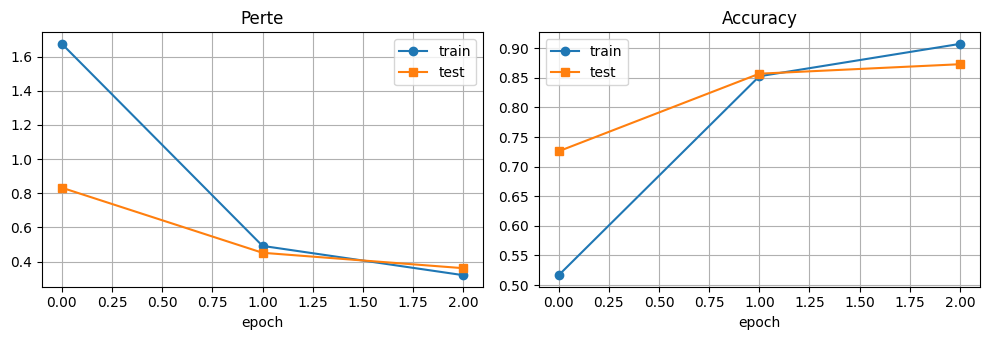

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(history["train_loss"], "o-", label="train")
axes[0].plot(history["test_loss"], "s-", label="test")
axes[0].set_title("Perte")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(True)
axes[1].plot(history["train_acc"], "o-", label="train")
axes[1].plot(history["test_acc"], "s-", label="test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()

## Exercice 4 — Erreurs

127 erreurs sur 1000


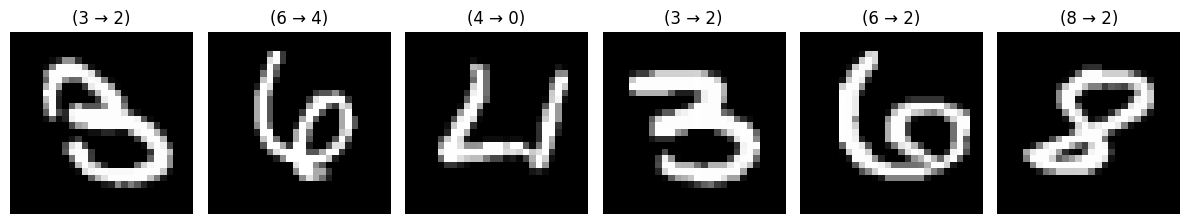

In [8]:
model.eval()
all_x, all_y, all_pred = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        pred = model(x.to(DEVICE)).argmax(1).cpu()
        all_x.append(x)
        all_y.append(y)
        all_pred.append(pred)
X = torch.cat(all_x)
Y = torch.cat(all_y)
P = torch.cat(all_pred)
wrong = torch.where(P != Y)[0]
print(f"{len(wrong)} erreurs sur {len(Y)}")

n_show = min(6, len(wrong))
fig, axes = plt.subplots(1, n_show, figsize=(2 * n_show, 2.5))
for ax, idx in zip(np.atleast_1d(axes), wrong[:n_show]):
    ax.imshow(X[idx].squeeze().numpy(), cmap="gray")
    ax.set_title(f"({int(Y[idx])} → {int(P[idx])})")
    ax.axis("off")
plt.tight_layout()